In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,NeuralNet,MultiModalAlignMamba
import torch.nn.functional as F
from einops import rearrange, repeat
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
#生物标志物 ad 90*48   no 349*58
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('normal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'normal_nii_kg/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('AD.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'ad_nii_KG/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('mci.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'NC_nii_kg/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #151
print(count_no) #211
print(count_mci) #475

151
211
475


In [4]:
# 基础替换字典
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0', 'ind':'3', 'ans':'4'}

# 隔离诊断标签的列索引提取规则
# EHR (14维): age(2), gender(3), education(4), hispanic(5), race(6) + his_系列(57-65)
ehr_cols = [2, 3, 4, 5, 6] + list(range(57, 66))
# BIO (39维): apoe(7) + mmse/cdr(20-22) + gds/moca(66, 67) + trail/npiq/faq等(24-56)
bio_cols = [7, 20, 21, 22, 66, 67] + list(range(24, 57))

# 统一且安全的预处理函数
def preprocess_data(data, replace_dict, target_cols):
    processed_data = []
    for row in data:
        extracted_row = [row[idx] for idx in target_cols]
        extracted_row = [replace_dict.get(item, item) for item in extracted_row]
        numerical_row = []
        for item in extracted_row:
            try:
                val = float(item)
                if math.isnan(val):
                    val = np.nan
            except ValueError:
                val = np.nan
            numerical_row.append(val)
        processed_data.append(numerical_row)
    return np.array(processed_data, dtype=float)

# 1. 提取 BIO 数组 (39 维特征)
ad_array = preprocess_data(data_ad, replace_dict, bio_cols)

normal_array = preprocess_data(data_normal, replace_dict, bio_cols)
mci_array = preprocess_data(data_mci, replace_dict, bio_cols)
print('ad.BIO--->', ad_array.shape)
print('normal.BIO--->', normal_array.shape)
print('mci.BIO--->', mci_array.shape)

ad.BIO---> (151, 39)
normal.BIO---> (211, 39)
mci.BIO---> (475, 39)


In [5]:
#加权算值
def weighted_sum(tensor):
    weights = [0.2, 0.3, 0.5]
    weight_tensor = torch.tensor(weights, dtype=tensor.dtype, device=tensor.device)
    weighted_sum_result = torch.sum(tensor * weight_tensor, dim=1, keepdim=True)
    return weighted_sum_result

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F  # 推荐：引入激活函数库

# 1. 转换数据为 Tensor
ad_tensor = torch.from_numpy(ad_array).float()
normal_tensor = torch.from_numpy(normal_array).float()
mci_tensor = torch.from_numpy(mci_array).float()

# 2. 定义网络层 
# 关键修复：输入维度改为 39（BIO 特征维度）
# 关键优化：使用不同的变量名 (fc1, fc2, fc3) 防止层被覆盖
fc1 = nn.Linear(39, 32)
fc2 = nn.Linear(32, 16)
fc3 = nn.Linear(16, 1)

# 3. 前向传播
# 注意：多层网络通常需要在层与层之间加激活函数(如 ReLU)，否则它数学上等价于单层网络。
# 为了保持代码运行，这里先按你的逻辑写，如果需要增加非线性能力，请取消注释 relu 行。

# 第一层
ad_tensor = fc1(ad_tensor)
# ad_tensor = F.relu(ad_tensor) 
normal_tensor = fc1(normal_tensor)
# normal_tensor = F.relu(normal_tensor)
mci_tensor = fc1(mci_tensor)
# mci_tensor = F.relu(mci_tensor)

# 第二层
ad_tensor = fc2(ad_tensor)
# ad_tensor = F.relu(ad_tensor)
normal_tensor = fc2(normal_tensor)
# normal_tensor = F.relu(normal_tensor)
mci_tensor = fc2(mci_tensor)
# mci_tensor = F.relu(mci_tensor)

# 第三层 (输出层)
ad_tensor = fc3(ad_tensor)
normal_tensor = fc3(normal_tensor)
mci_tensor = fc3(mci_tensor)

# 4. 打印结果
print('AD_tensor shape:', ad_tensor.shape)      # 预期: (151, 1)
print('Normal_tensor shape:', normal_tensor.shape) # 预期: (211, 1)
print('MCI_tensor shape:', mci_tensor.shape)    # 预期: (475, 1)

AD_tensor shape: torch.Size([151, 1])
Normal_tensor shape: torch.Size([211, 1])
MCI_tensor shape: torch.Size([475, 1])


In [7]:
# 编码类别型变量
def encode_categorical(data, categorical_indices):
    encoded_data = data.copy()
    for idx in categorical_indices:
        le = LabelEncoder()
        encoded_data[:, idx] = le.fit_transform(encoded_data[:, idx])
    return encoded_data.astype(float)

In [8]:
ad_data = preprocess_data(data_ad, replace_dict, ehr_cols)
normal_data = preprocess_data(data_normal, replace_dict, ehr_cols)
mci_data = preprocess_data(data_mci, replace_dict, ehr_cols)

categorical_indices = [1, 2, 3, 4]  # gender, education, hispanic, race
ad_EHR = encode_categorical(ad_data, categorical_indices)
normal_EHR = encode_categorical(normal_data, categorical_indices)
mci_EHR = encode_categorical(mci_data, categorical_indices)

ad_EHR = torch.from_numpy(ad_EHR).float()
normal_EHR = torch.from_numpy(normal_EHR).float()
mci_EHR = torch.from_numpy(mci_EHR).float()

linear_layer = nn.Linear(14, 16)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

linear_layer = nn.Linear(16, 1)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

print('ad.EHR--->',ad_EHR.shape)
print('normal.EHR--->',normal_EHR.shape)
print('mci.EHR--->',mci_EHR.shape)

ad.EHR---> torch.Size([151, 1])
normal.EHR---> torch.Size([211, 1])
mci.EHR---> torch.Size([475, 1])


In [9]:
#医学图像
nii = CNN_3D(num_class=1)
nii = nii.to(device)
all_ad = 'ad_nii_KG/'
all_normal = 'normal_nii_kg/'
all_mci = 'NC_nii_kg/'

# 打印原始 NIfTI tensor 形状，确保 MRI 提取的 nii.shape 可见

def print_raw_nii_shape(folder, label):
    dataset = NiiDataset(folder)
    if len(dataset) == 0:
        print(f'{label} raw nii tensor shape---> empty dataset')
        return
    print(f'{label} raw nii tensor shape--->', dataset[0].shape)

print_raw_nii_shape(all_ad, 'ad')
print_raw_nii_shape(all_normal, 'normal')
print_raw_nii_shape(all_mci, 'mci')

dataset = NiiDataset(all_ad)
batch_size = 16
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
ad_output = torch.cat(all_outputs, dim=0)

dataset = NiiDataset(all_normal)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
normal_output = torch.cat(all_outputs, dim=0)

dataset = NiiDataset(all_mci)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []
for batch_idx, batch_data in enumerate(dataloader):
    batch_data = batch_data.to(device)
    output = nii(batch_data)
    all_outputs.append(output)
mci_output = torch.cat(all_outputs, dim=0)

ad raw nii tensor shape---> torch.Size([1, 64, 64, 64])
normal raw nii tensor shape---> torch.Size([1, 64, 64, 64])
mci raw nii tensor shape---> torch.Size([1, 64, 64, 64])


In [10]:
print('ad.BIO--->', ad_tensor.shape)
print('normal.BIO--->', normal_tensor.shape)
print('mci.BIO--->', mci_tensor.shape)
print('ad.EHR--->', ad_EHR.shape)
print('normal.EHR--->', normal_EHR.shape)
print('mci.EHR--->', mci_EHR.shape)
print('ad nii shape--->', ad_output.shape)
print('normal nii shape--->', normal_output.shape)
print('mci nii shape--->', mci_output.shape)

ad.BIO---> torch.Size([151, 1])
normal.BIO---> torch.Size([211, 1])
mci.BIO---> torch.Size([475, 1])
ad.EHR---> torch.Size([151, 1])
normal.EHR---> torch.Size([211, 1])
mci.EHR---> torch.Size([475, 1])
ad nii shape---> torch.Size([151, 1])
normal nii shape---> torch.Size([211, 1])
mci nii shape---> torch.Size([475, 1])


In [11]:
ad_EHR = ad_EHR.cpu()
ad_tensor = ad_tensor.cpu()
mci_EHR = mci_EHR.cpu()
mci_tensor = mci_tensor.cpu()
normal_EHR = normal_EHR.cpu()
normal_tensor = normal_tensor.cpu()
ad_output = ad_output.cpu()
mci_output = mci_output.cpu()
normal_output = normal_output.cpu()

X_ad = torch.cat([ad_EHR, ad_output, ad_tensor], dim=1)
X_mci = torch.cat([mci_EHR, mci_output, mci_tensor], dim=1)
X_normal = torch.cat([normal_EHR, normal_output, normal_tensor], dim=1)
y_ad = torch.ones(len(X_ad)) * 2  # AD 类别标签为 2
y_mci = torch.ones(len(X_mci)) * 1  # MCI 类别标签为 1
y_normal = torch.ones(len(X_normal)) * 0  # Nc 类别标签为 0
# 拼接特征和标签
X = torch.cat([X_ad, X_mci, X_normal], dim=0).float()
y = torch.cat([y_ad, y_mci, y_normal], dim=0).float()

# 数据划分
X_train, X_test, y_train, y_test = train_test_split(X.detach().numpy(), y.numpy(),
                                                    test_size=0.25,
                                                    stratify=y.numpy(),
                                                    random_state=34)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                  test_size=0.25,
                                                  stratify=y_train,
                                                  random_state=34)

In [12]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

# 创建 TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [13]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [14]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.long()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        # 获取预测概率
        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc

In [15]:
def evaluate(model, loader):
    model.eval()
    all_probs = []
    all_labels = []
    total_loss = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.long()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            # 获取预测概率
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
    test_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, test_auc

In [16]:
train_losses = []
train_aucs = []
test_losses = []
test_aucs = []
# 将原本的 MultiModalTransformer 替换为新模型
model = MultiModalAlignMamba(embed_dim=16, d_state=16, num_heads=2, dropout=0.2)
model = model.to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()    
for epoch in range(201):
    train_loss, train_auc = train_epoch(model, train_loader)
    test_loss, test_auc = evaluate(model, test_loader)
        
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    print(f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | "
            f"Test Loss: {test_loss:.4f} | Test AUC: {test_auc:.4f}")

Epoch 000 | Train Loss: 1.1511 | Train AUC: 0.5051 | Test Loss: 1.1327 | Test AUC: 0.4961
Epoch 001 | Train Loss: 1.1278 | Train AUC: 0.5425 | Test Loss: 1.1336 | Test AUC: 0.5287
Epoch 002 | Train Loss: 1.1401 | Train AUC: 0.5134 | Test Loss: 1.1363 | Test AUC: 0.5389
Epoch 003 | Train Loss: 1.1145 | Train AUC: 0.5653 | Test Loss: 1.1288 | Test AUC: 0.5448
Epoch 004 | Train Loss: 1.1021 | Train AUC: 0.5763 | Test Loss: 1.1157 | Test AUC: 0.5575
Epoch 005 | Train Loss: 1.1181 | Train AUC: 0.5332 | Test Loss: 1.1162 | Test AUC: 0.5581
Epoch 006 | Train Loss: 1.0911 | Train AUC: 0.5905 | Test Loss: 1.1063 | Test AUC: 0.5670
Epoch 007 | Train Loss: 1.0939 | Train AUC: 0.5808 | Test Loss: 1.1146 | Test AUC: 0.5733
Epoch 008 | Train Loss: 1.0926 | Train AUC: 0.5809 | Test Loss: 1.0971 | Test AUC: 0.5630
Epoch 009 | Train Loss: 1.1003 | Train AUC: 0.5535 | Test Loss: 1.0961 | Test AUC: 0.5752
Epoch 010 | Train Loss: 1.0947 | Train AUC: 0.5692 | Test Loss: 1.1013 | Test AUC: 0.5797
Epoch 011 

In [17]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
# 获取预测类别
preds = np.argmax(all_probs, axis=1)
# 计算指标
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro') 
recall = recall_score(all_labels, preds, average='macro')       
f1 = f1_score(all_labels, preds, average='macro')               
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')  
print("\n=== Final Test Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Test Metrics ===
Accuracy:  0.5851
Precision: 0.4854
Recall:    0.4980
F1 Score:  0.4710
AUC-ROC:   0.7691


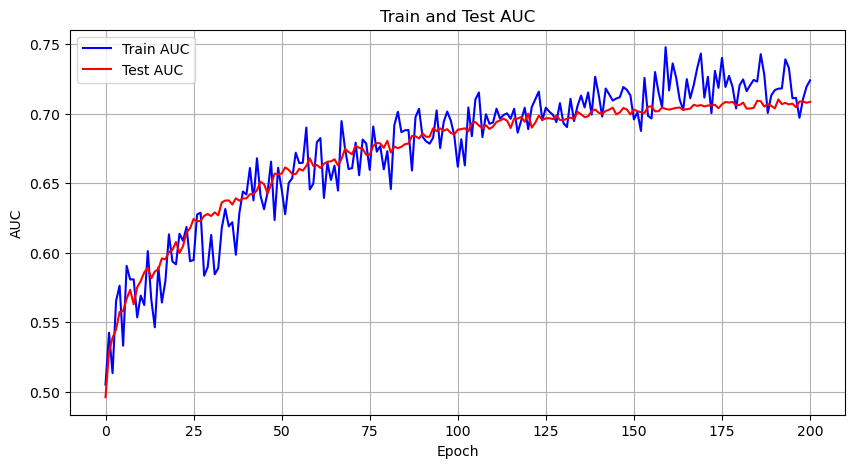

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("Train and Test AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

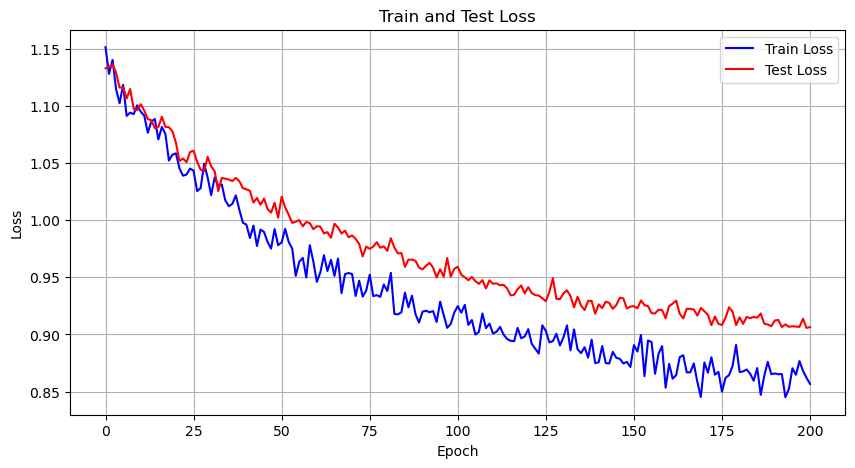

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("Train and Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
def evaluate_model():
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['NC', 'MCI', 'AD']))
    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')  # 使用 'ovr' 或 'ovo'
    print(f"AUC Score (Ovr): {auc:.4f}")

evaluate_model()


Classification Report:
              precision    recall  f1-score   support

          NC       0.40      0.20      0.27        40
         MCI       0.65      0.75      0.70        89
          AD       0.50      0.61      0.55        28

    accuracy                           0.59       157
   macro avg       0.52      0.52      0.50       157
weighted avg       0.56      0.59      0.56       157

Confusion Matrix:
[[ 8 28  4]
 [ 9 67 13]
 [ 3  8 17]]
AUC Score (Ovr): 0.7589
